# Hotel Reservation Data Analysis
### Understanding Booking Trends and Customer Behavior
In this project, I analyze a dataset of hotel reservations to uncover patterns in booking behavior, cancellation rates,
seasonal trends, and factors influencing customer decisions.

**Dataset:** [Hotel booking demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)
(Antonio, Almeida & Nunes, 2019). Download it and save it next to this notebook as `Hotel_Bookings.csv`.
The data covers arrivals from **July 2015 to August 2017**.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import numpy as np
import pandas as pd

TITLE_STYLE = dict(loc='left', weight='bold', color='slategray')
LABEL_STYLE = dict(weight='bold', color='slategray')
HOTEL_COLORS = {'City Hotel': 'lightgreen', 'Resort Hotel': 'thistle'}
MONTH_ORDER = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

Import the reservation data

In [2]:
DATA_PATH = Path('Hotel_Bookings.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Download the dataset from "
        "https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand "
        "and save it next to this notebook."
    )

data = pd.read_csv(DATA_PATH)
print(data.shape)
data.head()

(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Data cleaning
- Replace the `NaN` values of `company`, `children` and `agent` with `0` and convert them to `int`.
- Remove exact duplicate rows.
- Remove invalid rows: bookings with no guests at all, and rows with a negative daily rate (`adr`).
- Remove the single `adr = 5400` booking, which is a data entry error (more than 10x the next highest price).
- Build helper columns: total nights and **revenue** (`adr` is the *average daily rate*, so a booking's revenue
  is `adr × nights`; cancelled bookings earn no revenue).

In [3]:
for col in ['company', 'children', 'agent']:
    data[col] = data[col].fillna(0).astype(int)

rows_before = len(data)
data = data.drop_duplicates()
print(f'Duplicates removed: {rows_before - len(data)}')

no_guests = (data['adults'] + data['children'] + data['babies']) == 0
invalid_adr = (data['adr'] < 0) | (data['adr'] > 1000)
print(f'Bookings without guests removed: {no_guests.sum()}')
print(f'Bookings with an invalid adr removed: {invalid_adr.sum()}')
data = data[~no_guests & ~invalid_adr].copy()

data['total_nights'] = data['stays_in_weekend_nights'] + data['stays_in_week_nights']
data['revenue'] = np.where(data['is_canceled'] == 0, data['adr'] * data['total_nights'], 0)
data['arrival_date_month'] = pd.Categorical(data['arrival_date_month'], categories=MONTH_ORDER, ordered=True)

print(f'Rows after cleaning: {len(data)}')

Duplicates removed: 31994
Bookings without guests removed: 166
Bookings with an invalid adr removed: 2
Rows after cleaning: 87228


This plot shows the number of total reservations in every hotel.

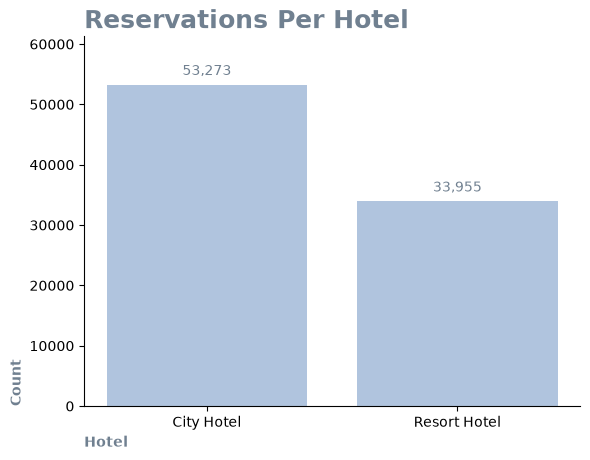

City Hotel is booked 1.57 times more than Resort Hotel.


In [4]:
hotel_types = data['hotel'].value_counts()

fig, ax = plt.subplots()
ax.bar(hotel_types.index, hotel_types.values, color='lightsteelblue')
for i, value in enumerate(hotel_types.values):
    ax.text(i, value + 0.03 * hotel_types.max(), f'{value:,}', ha='center', fontsize=10, color='slategray')
ax.set_ylim(0, hotel_types.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)

ax.set_title('Reservations Per Hotel', fontsize=18, **TITLE_STYLE)
ax.set_xlabel('Hotel', loc='left', **LABEL_STYLE)
ax.set_ylabel('Count', loc='bottom', **LABEL_STYLE)
plt.show()

print(f"City Hotel is booked {hotel_types['City Hotel'] / hotel_types['Resort Hotel']:.2f} times more than Resort Hotel.")

In this plot we can see what percentage of reservations are cancelled.

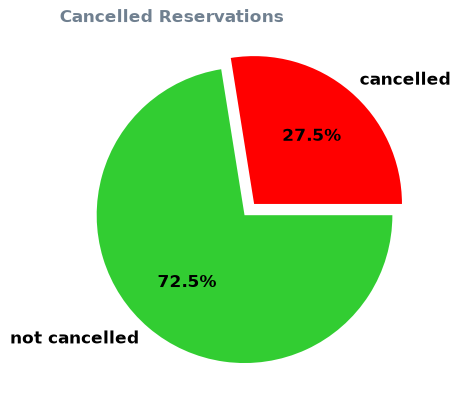

In [5]:
cancel_counts = data['is_canceled'].value_counts()
explode = [0.1, 0]

fig, ax = plt.subplots()
ax.pie([cancel_counts[1], cancel_counts[0]], labels=['cancelled', 'not cancelled'], explode=explode,
       colors=['red', 'limegreen'], textprops={'fontsize': 12, 'fontweight': 'bold'}, autopct='%1.1f%%')
ax.set_title('Cancelled Reservations', **TITLE_STYLE)
plt.show()

Cancellation rate of each hotel.

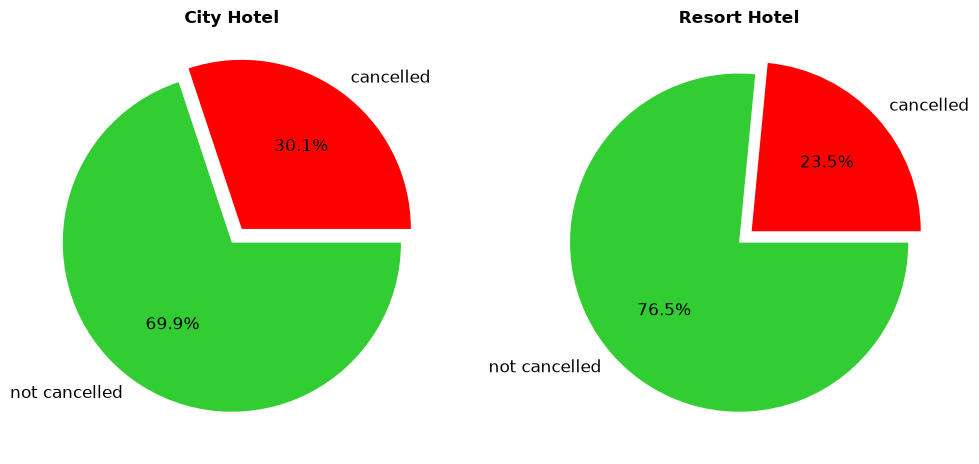

hotel
City Hotel      30.1
Resort Hotel    23.5
Difference: 6.6 percentage points


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, hotel in zip(axes, ['City Hotel', 'Resort Hotel']):
    counts = data.loc[data['hotel'] == hotel, 'is_canceled'].value_counts()
    ax.pie([counts[1], counts[0]], labels=['cancelled', 'not cancelled'], explode=explode,
           colors=['red', 'limegreen'], textprops={'fontsize': 12}, autopct='%1.1f%%')
    ax.set_title(hotel, fontweight='bold')
plt.show()

cancel_rate = data.groupby('hotel')['is_canceled'].mean() * 100
print(cancel_rate.round(1).to_string())
print(f"Difference: {cancel_rate['City Hotel'] - cancel_rate['Resort Hotel']:.1f} percentage points")

### Reservations per year and room type
The year is taken from the **arrival date**. (`reservation_status_date` is the date the booking was last
updated, e.g. cancelled or checked out, so it does not describe when guests stayed.)

Note that **2015 (July–December) and 2017 (January–August) are partial years**, so only 2016 is a full year.

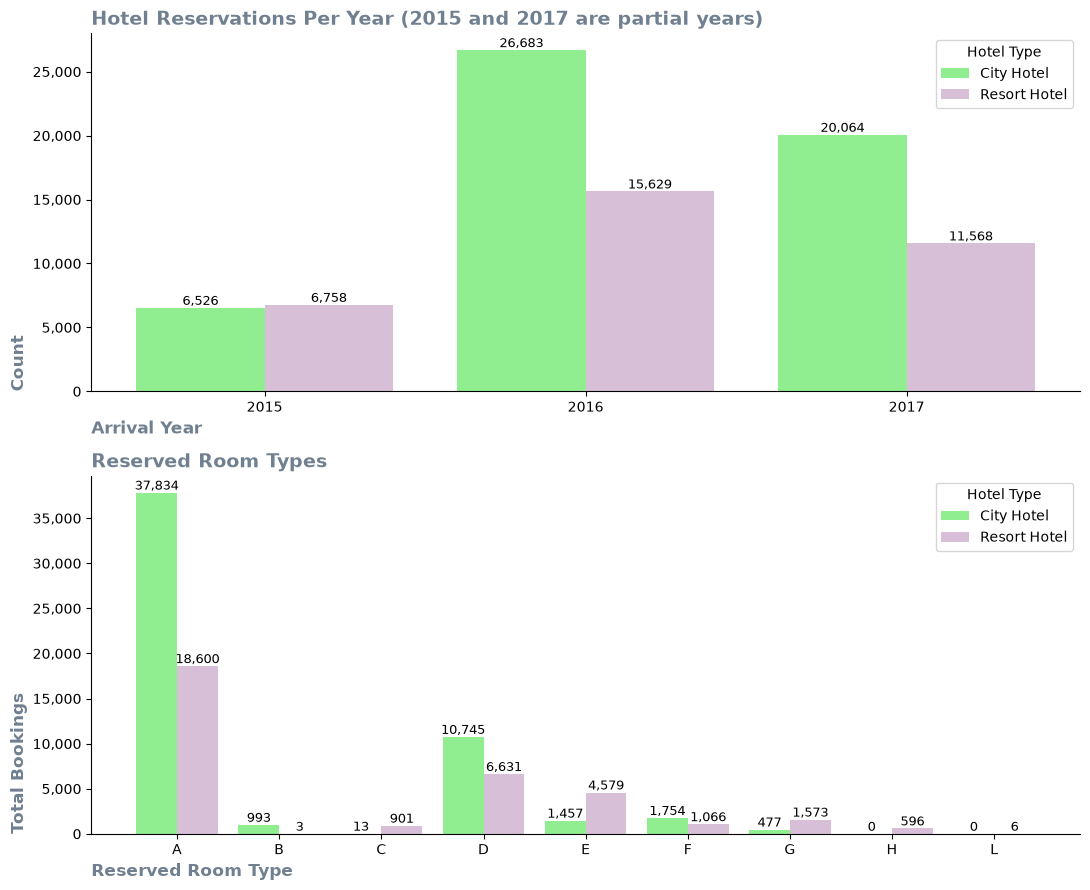

Share of bookings per room type (%):
reserved_room_type
A    64.7
D    19.9
E     6.9
F     3.2
G     2.4
B     1.1
C     1.0
H     0.7
L     0.0


In [7]:
def add_bar_labels(ax, bars, fmt='{:,.0f}', horizontal=False):
    for bar in bars:
        if horizontal:
            value = bar.get_width()
            ax.text(value, bar.get_y() + bar.get_height() / 2, ' ' + fmt.format(value), va='center', fontsize=9)
        else:
            value = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, value, fmt.format(value), ha='center', va='bottom', fontsize=9)


def grouped_bars(ax, table, width=0.4, fmt='{:,.0f}'):
    x = np.arange(len(table.index))
    for offset, hotel in zip([-width / 2, width / 2], ['City Hotel', 'Resort Hotel']):
        bars = ax.bar(x + offset, table[hotel], width, label=hotel, color=HOTEL_COLORS[hotel])
        add_bar_labels(ax, bars, fmt)
    ax.set_xticks(x)
    ax.set_xticklabels(table.index.astype(str))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(title='Hotel Type')


yearly = data.groupby(['arrival_date_year', 'hotel']).size().unstack(fill_value=0)
rooms = data.groupby(['reserved_room_type', 'hotel']).size().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), gridspec_kw={'height_ratios': [1, 1]})

grouped_bars(ax1, yearly)
ax1.set_title('Hotel Reservations Per Year (2015 and 2017 are partial years)', fontsize=14, **TITLE_STYLE)
ax1.set_xlabel('Arrival Year', loc='left', fontsize=12, **LABEL_STYLE)
ax1.set_ylabel('Count', loc='bottom', fontsize=12, **LABEL_STYLE)

grouped_bars(ax2, rooms)
ax2.set_title('Reserved Room Types', fontsize=14, **TITLE_STYLE)
ax2.set_xlabel('Reserved Room Type', loc='left', fontsize=12, **LABEL_STYLE)
ax2.set_ylabel('Total Bookings', loc='bottom', fontsize=12, **LABEL_STYLE)

plt.tight_layout()
plt.show()

room_share = data['reserved_room_type'].value_counts(normalize=True).mul(100).round(1)
print('Share of bookings per room type (%):')
print(room_share.to_string())

### Revenue
Revenue is computed from **non-cancelled** bookings only, as `adr × total nights`.

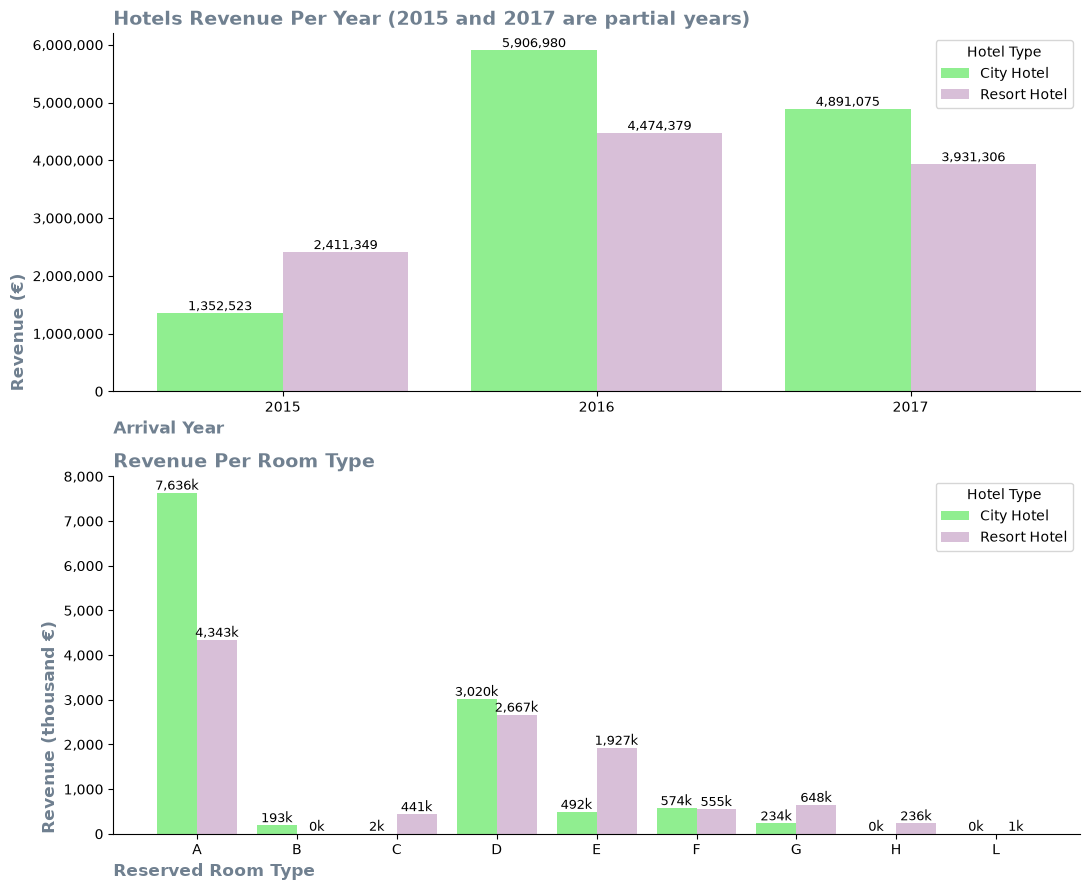

Total revenue per hotel (€):
hotel
City Hotel      12,150,578
Resort Hotel    10,817,034


In [8]:
yearly_revenue = data.groupby(['arrival_date_year', 'hotel'])['revenue'].sum().unstack(fill_value=0)
room_revenue = data.groupby(['reserved_room_type', 'hotel'])['revenue'].sum().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9))

grouped_bars(ax1, yearly_revenue)
ax1.set_title('Hotels Revenue Per Year (2015 and 2017 are partial years)', fontsize=14, **TITLE_STYLE)
ax1.set_xlabel('Arrival Year', loc='left', fontsize=12, **LABEL_STYLE)
ax1.set_ylabel('Revenue (€)', loc='bottom', fontsize=12, **LABEL_STYLE)

grouped_bars(ax2, room_revenue / 1000, fmt='{:,.0f}k')
ax2.set_title('Revenue Per Room Type', fontsize=14, **TITLE_STYLE)
ax2.set_xlabel('Reserved Room Type', loc='left', fontsize=12, **LABEL_STYLE)
ax2.set_ylabel('Revenue (thousand €)', loc='bottom', fontsize=12, **LABEL_STYLE)

plt.tight_layout()
plt.show()

print('Total revenue per hotel (€):')
print(data.groupby('hotel')['revenue'].sum().map('{:,.0f}'.format).to_string())

### Room prices
Average daily rate (`adr`) distribution of each hotel. A box plot shows the median, the quartiles and the spread;
the table below gives the exact statistics.

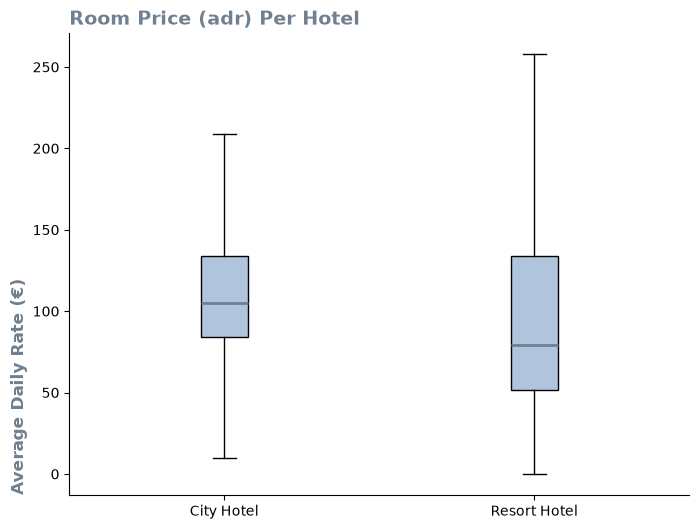

,count,mean,std,min,25%,50%,75%,max
hotel,,,,,,,,
City Hotel,53273.0,111.2,42.0,0.0,84.2,105.3,134.1,510.0
Resort Hotel,33955.0,99.1,63.8,0.0,51.5,79.5,134.1,508.0


In [9]:
hotels = ['City Hotel', 'Resort Hotel']
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot([data.loc[data['hotel'] == h, 'adr'] for h in hotels], showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'), medianprops=dict(color='slategray', linewidth=2))
ax.set_xticks([1, 2])
ax.set_xticklabels(hotels)
ax.set_title('Room Price (adr) Per Hotel', fontsize=14, **TITLE_STYLE)
ax.set_ylabel('Average Daily Rate (€)', loc='bottom', fontsize=12, **LABEL_STYLE)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

data.groupby('hotel')['adr'].describe().round(1)

Top 10 nationalities of the guests.

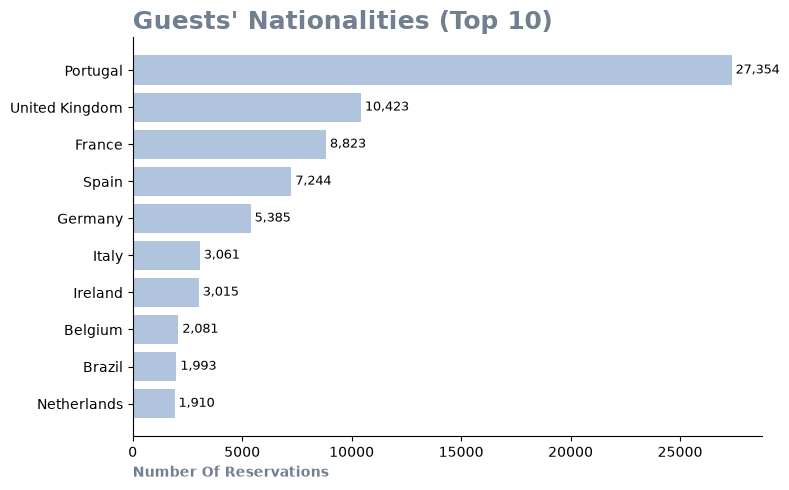

In [10]:
COUNTRY_NAMES = {
    'PRT': 'Portugal', 'GBR': 'United Kingdom', 'FRA': 'France', 'ESP': 'Spain', 'DEU': 'Germany',
    'ITA': 'Italy', 'IRL': 'Ireland', 'BEL': 'Belgium', 'BRA': 'Brazil', 'NLD': 'Netherlands',
    'USA': 'United States', 'CHE': 'Switzerland', 'CN': 'China', 'AUT': 'Austria', 'SWE': 'Sweden',
}

top_countries = data['country'].value_counts().head(10)
labels = [COUNTRY_NAMES.get(code, code) for code in top_countries.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels[::-1], top_countries.values[::-1], color='lightsteelblue')
add_bar_labels(ax, bars, horizontal=True)
ax.set_title('Guests\' Nationalities (Top 10)', fontsize=18, **TITLE_STYLE)
ax.set_xlabel('Number Of Reservations', loc='left', **LABEL_STYLE)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Reservations per market segment (the 2 bookings with an `Undefined` segment are excluded).

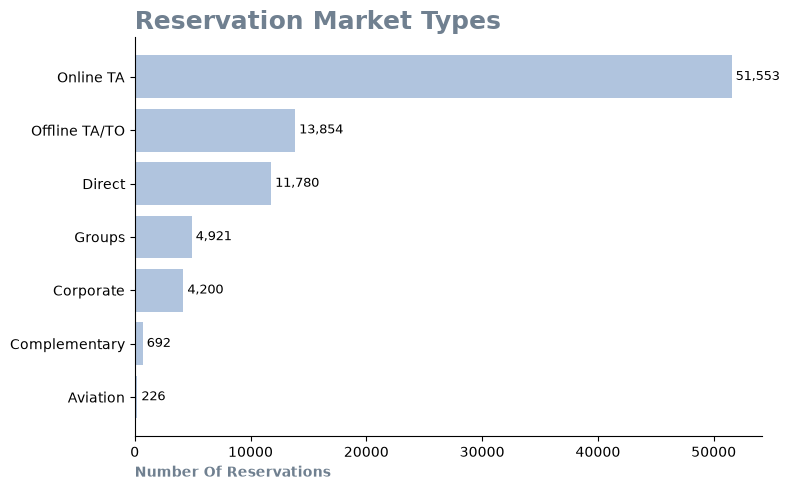

market_segment
Online TA        59.1
Offline TA/TO    15.9
Direct           13.5
Groups            5.6
Corporate         4.8
Complementary     0.8
Aviation          0.3


In [11]:
segments = data.loc[data['market_segment'] != 'Undefined', 'market_segment'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(segments.index, segments.values, color='lightsteelblue')
add_bar_labels(ax, bars, horizontal=True)
ax.set_title('Reservation Market Types', fontsize=18, **TITLE_STYLE)
ax.set_xlabel('Number Of Reservations', loc='left', **LABEL_STYLE)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print((segments / segments.sum() * 100).round(1).sort_values(ascending=False).to_string())

### Seasonality
The dataset contains **three** Julys and Augusts (2015, 2016, 2017) but only **two** of every other month, and the
number of bookings grows from year to year. Counting all bookings per month would therefore inflate July and August.
To compare months fairly, the chart uses **2016, the only complete year** in the data.

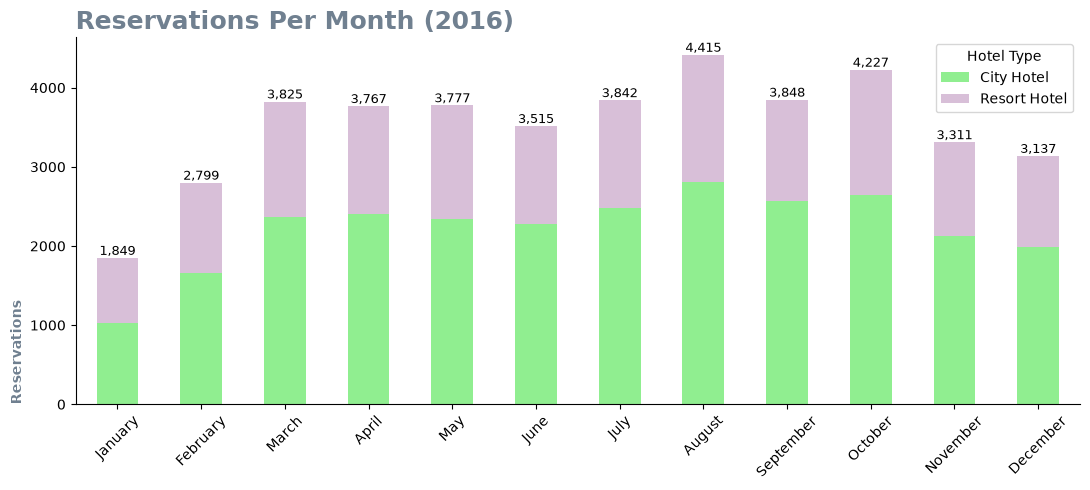

In [12]:
FULL_YEAR = 2016
monthly = (data[data['arrival_date_year'] == FULL_YEAR]
           .groupby(['arrival_date_month', 'hotel'], observed=True).size().unstack())

fig, ax = plt.subplots(figsize=(11, 5))
monthly.plot(kind='bar', stacked=True, color=[HOTEL_COLORS[h] for h in monthly.columns], ax=ax)
for i, total in enumerate(monthly.sum(axis=1)):
    ax.text(i, total, f'{total:,}', ha='center', va='bottom', fontsize=9)
ax.set_title(f'Reservations Per Month ({FULL_YEAR})', fontsize=18, **TITLE_STYLE)
ax.set_xlabel('')
ax.set_ylabel('Reservations', loc='bottom', **LABEL_STYLE)
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

More bookings naturally means more cancellations, so the absolute number of cancellations is not very informative.
The **cancellation rate** (cancelled / all bookings of that month) shows whether guests actually cancel more
in some months.

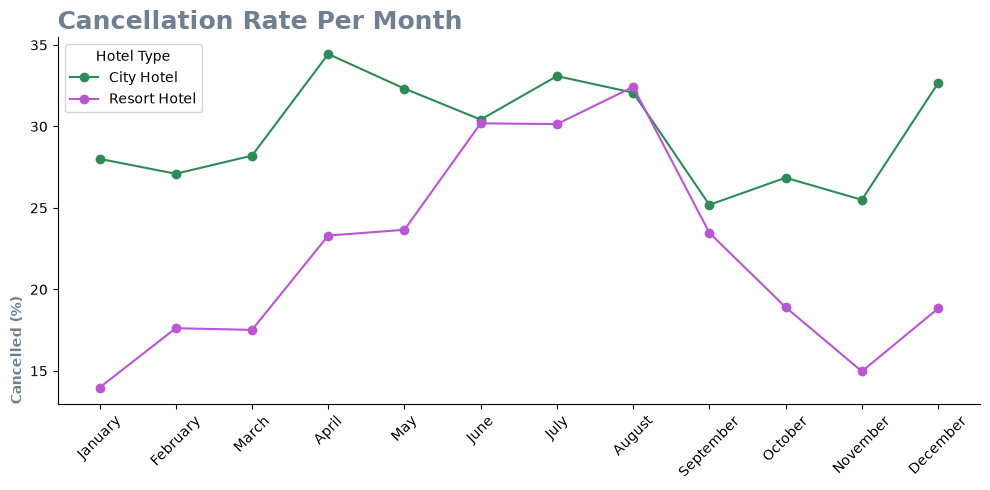

In [13]:
monthly_cancel_rate = data.groupby(['arrival_date_month', 'hotel'], observed=True)['is_canceled'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10, 5))
for hotel in hotels:
    ax.plot(monthly_cancel_rate.index.astype(str), monthly_cancel_rate[hotel], marker='o',
            label=hotel, color={'City Hotel': 'seagreen', 'Resort Hotel': 'mediumorchid'}[hotel])
ax.set_title('Cancellation Rate Per Month', fontsize=18, **TITLE_STYLE)
ax.set_ylabel('Cancelled (%)', loc='bottom', **LABEL_STYLE)
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

### Lead time and cancellations
One of the project objectives is to study the impact of lead time (days between booking and arrival).
Bookings are grouped into lead-time ranges and the cancellation rate of each range is shown.

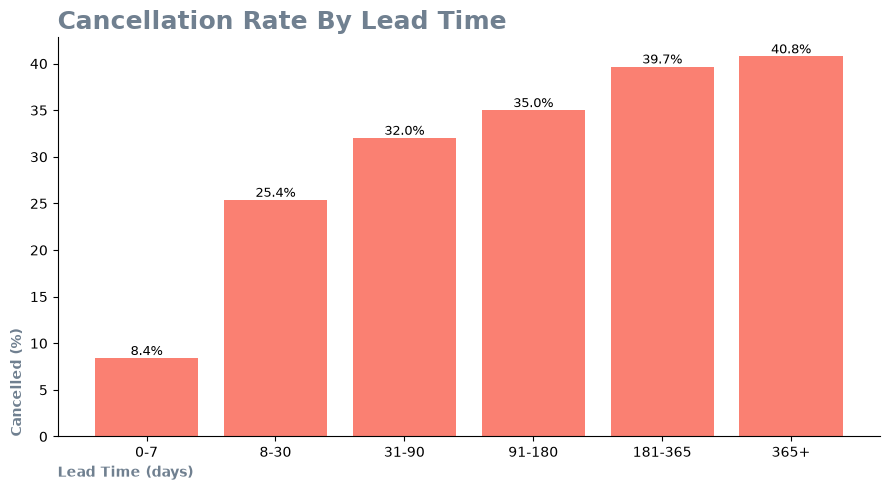

,cancel rate,bookings
lead_time_group,,
0-7,0.084,18203
8-30,0.254,16326
31-90,0.320,22719
91-180,0.350,18224
181-365,0.397,11192
365+,0.408,564


In [14]:
bins = [-1, 7, 30, 90, 180, 365, data['lead_time'].max()]
bin_labels = ['0-7', '8-30', '31-90', '91-180', '181-365', '365+']
data['lead_time_group'] = pd.cut(data['lead_time'], bins=bins, labels=bin_labels)

lead_cancel = data.groupby('lead_time_group', observed=True)['is_canceled'].agg(['mean', 'size'])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(lead_cancel.index.astype(str), lead_cancel['mean'] * 100, color='salmon')
add_bar_labels(ax, bars, fmt='{:.1f}%')
ax.set_title('Cancellation Rate By Lead Time', fontsize=18, **TITLE_STYLE)
ax.set_xlabel('Lead Time (days)', loc='left', **LABEL_STYLE)
ax.set_ylabel('Cancelled (%)', loc='bottom', **LABEL_STYLE)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

lead_cancel.rename(columns={'mean': 'cancel rate', 'size': 'bookings'}).round(3)

Cancellation rate per market segment and deposit type.

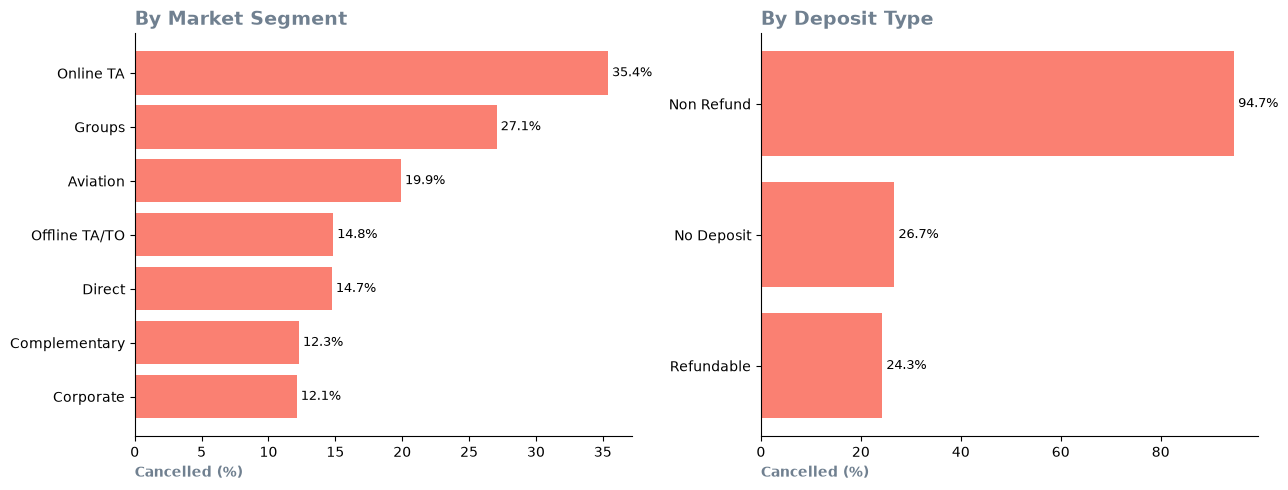

,mean,size
deposit_type,,
No Deposit,0.267,86084
Non Refund,0.947,1037
Refundable,0.243,107


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

seg_rate = (data.loc[data['market_segment'] != 'Undefined']
            .groupby('market_segment')['is_canceled'].mean().sort_values() * 100)
bars = ax1.barh(seg_rate.index, seg_rate.values, color='salmon')
add_bar_labels(ax1, bars, fmt='{:.1f}%', horizontal=True)
ax1.set_title('By Market Segment', fontsize=14, **TITLE_STYLE)
ax1.set_xlabel('Cancelled (%)', loc='left', **LABEL_STYLE)

dep_rate = data.groupby('deposit_type')['is_canceled'].mean().sort_values() * 100
bars = ax2.barh(dep_rate.index, dep_rate.values, color='salmon')
add_bar_labels(ax2, bars, fmt='{:.1f}%', horizontal=True)
ax2.set_title('By Deposit Type', fontsize=14, **TITLE_STYLE)
ax2.set_xlabel('Cancelled (%)', loc='left', **LABEL_STYLE)

for ax in (ax1, ax2):
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

data.groupby('deposit_type')['is_canceled'].agg(['mean', 'size']).round(3)

## Conclusion

**1. City Hotel has 1.57 times more reservations and more total revenue (≈ €12.2M vs €10.8M), but it also has a higher cancellation rate: 30.1% vs 23.5% for Resort Hotel (6.6 percentage points more).**

**2. Room type __A__ is by far the most booked (≈ 65% of bookings), followed by __D__ (≈ 20%), __E__ (≈ 7%) and __F__ (≈ 3%). The same room types also bring the most revenue.**

**3. City Hotel rooms are more expensive on average (median adr ≈ €105 vs €80), while Resort Hotel prices vary much more (std ≈ €64 vs €42) because of strong seasonal pricing. The very large maximum price seen in the raw data (€5,400) was a single data entry error and was removed.**

**4. Portugal, United Kingdom, France, Spain and Germany are the 5 top nationalities of the guests; Portugal alone accounts for about 31% of all bookings.**

**5. Online travel agencies have the greater part of the market (≈ 59% of bookings), followed by offline travel agencies (≈ 16%) and direct bookings (≈ 14%).**

**6. In 2016 (the only complete year), January and February are the quietest months, March–July stay at a steady level (≈ 3,500–3,850 bookings), August is the peak month and October is the second busiest. The cancellation rate of Resort Hotel is clearly seasonal (lowest in winter, highest in summer), while City Hotel stays between ~25% and ~35% all year.**

**7. Lead time is strongly related to cancellations: only ≈ 8% of bookings made within a week of arrival are cancelled, compared with ≈ 35–40% of bookings made more than 3 months in advance.**

**8. Surprisingly, "Non Refund" deposits have a ≈ 95% cancellation rate. These are mostly group bookings made through agencies, so this is a known quirk of the dataset rather than evidence that deposits encourage cancellations.**
